In [1]:
import itertools as it
import numpy as np
import pandas as pd
# Zarlar
dice = {
    'die1': [1, 2, 3, 4, 5, 6],
    'die2': [1, 2, 3, 4, 5, 6],
    'die3': [1, 2, 3, 4, 5, 6],
    'die4': [1, 2, 3, 4, 5, 6],
}

# Tüm kombinasyonlar
result = pd.DataFrame(it.product(*dice.values()), columns=dice.keys())
result

,die1,die2,die3,die4
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5
...,...,...,...,...
1291,6,6,6,2
1292,6,6,6,3
1293,6,6,6,4
1294,6,6,6,5


In [2]:
# Dört atışın ortalamasını, DataFrame'imize mean_roll adında bir sütun ekleyerek ele alalım
result['mean_roll'] = (result.die1 + result.die2 + result.die3 + result.die4) / 4
result

,die1,die2,die3,die4,mean_roll
0,1,1,1,1,1.00
1,1,1,1,2,1.25
2,1,1,1,3,1.50
3,1,1,1,4,1.75
4,1,1,1,5,2.00
...,...,...,...,...,...
1291,6,6,6,2,5.00
1292,6,6,6,3,5.25
1293,6,6,6,4,5.50
1294,6,6,6,5,5.75


(array([  5.,  30.,  91., 184., 265., 286., 229., 136.,  55.,  15.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

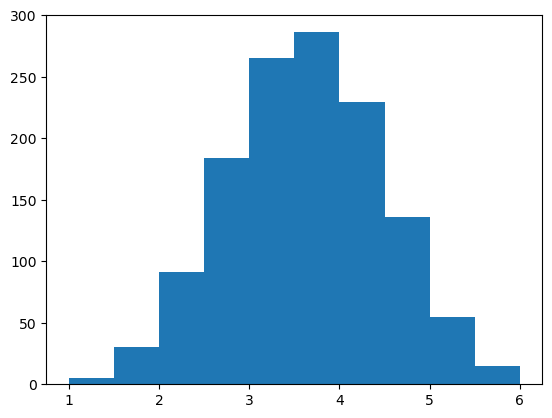

In [3]:
import matplotlib.pyplot as plt
#plt.hist(result["mean_roll"],bins=41)  aralığı 41 verirsek bar hist ile aynı sonucu verir. yani bu dağılımın aralığı az olduğundan alltaki gibi bir dağılım gözükmüyor
plt.hist(result["mean_roll"])
#deneme derste yok

"\n1. *Kategoriye Dönüştürme:*\n    python\n    result['mean_roll'] = result['mean_roll'].astype('category')\n    \n    Bu satır, result DataFrame'inde bulunan mean_roll sütunundaki değerleri category veri tipine dönüştürür.\n    Bu işlem, bu sütundaki verilerin kategori olarak ele alınmasını sağlar.\n\n2. *Değer Sayımlarını Hesaplama ve Bar Grafiği Çizme:*\n    python\n    result['mean_roll'].value_counts(sort=False).plot(kind='bar')\n    \n    Bu satır iki ana işlemi gerçekleştirir:\n    - value_counts(sort=False): mean_roll sütunundaki her bir kategorik değerin sıklığını\n    (kaç kez tekrarlandığını) hesaplar.\n    \n    sort=False parametresi, sonuçları sıralamadan döndürür.\n    \n    - plot(kind='bar'): Hesaplanan değer sayımlarını bir bar grafiği olarak çizer.\n    kind='bar', grafiğin türünün bar grafiği olduğunu belirtir.\n\n"

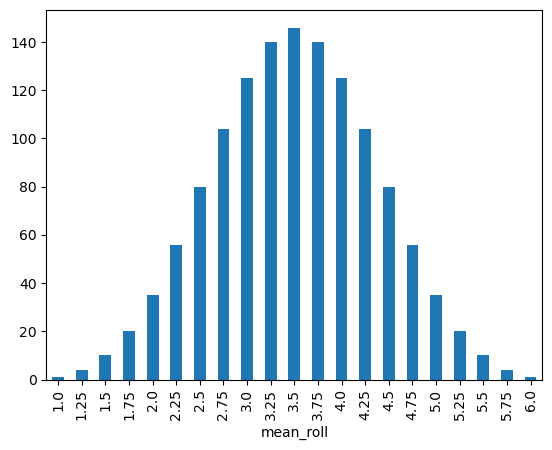

In [4]:
# mean_roll dağılımını görmek için bar grafiği çizelim
result['mean_roll'] = result['mean_roll'].astype('category') #sözele çevir
result['mean_roll'].value_counts(sort=False).plot(kind='bar')
'''
1. *Kategoriye Dönüştürme:*
    python
    result['mean_roll'] = result['mean_roll'].astype('category')
    
    Bu satır, result DataFrame'inde bulunan mean_roll sütunundaki değerleri category veri tipine dönüştürür.
    Bu işlem, bu sütundaki verilerin kategori olarak ele alınmasını sağlar.

2. *Değer Sayımlarını Hesaplama ve Bar Grafiği Çizme:*
    python
    result['mean_roll'].value_counts(sort=False).plot(kind='bar')
    
    Bu satır iki ana işlemi gerçekleştirir:
    - value_counts(sort=False): mean_roll sütunundaki her bir kategorik değerin sıklığını
    (kaç kez tekrarlandığını) hesaplar.
    
    sort=False parametresi, sonuçları sıralamadan döndürür.
    
    - plot(kind='bar'): Hesaplanan değer sayımlarını bir bar grafiği olarak çizer.
    kind='bar', grafiğin türünün bar grafiği olduğunu belirtir.

'''


<Axes: xlabel='n_dice', ylabel='n_outcomes'>

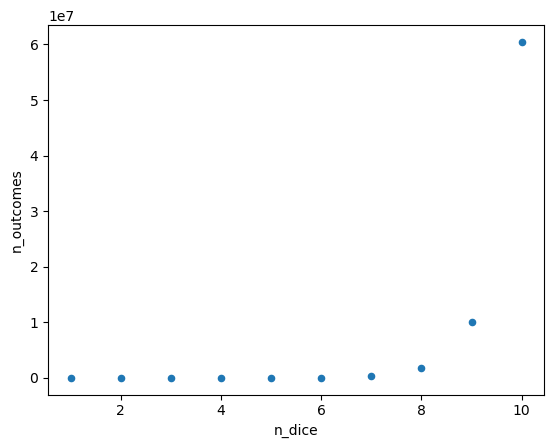

In [5]:
# aşağıdaki kod zarların tüm kombinasyonunu içerdiğinden ortalama silindirin
# tam örnekleme dağılımıdır

n_dice = list(range(1, 11))
n_outcomes = []

for n in n_dice:
    n_outcomes.append(6**n)

outcomes = pd.DataFrame({
    'n_dice': n_dice,
    'n_outcomes': n_outcomes
})

outcomes.plot(x='n_dice', y='n_outcomes', kind='scatter')

In [6]:
import numpy as np

sample_means_1000 = []

for i in range(1000):
    sample_means_1000.append(
        np.random.choice(list(range(1, 7)), size=4, replace=True).mean()
    )

(array([  1.,   9.,  15.,  33.,  37.,  57.,  94., 103., 107.,   0., 106.,
        104.,  86.,  97.,  55.,  50.,  27.,  13.,   5.,   1.]),
 array([1.25 , 1.475, 1.7  , 1.925, 2.15 , 2.375, 2.6  , 2.825, 3.05 ,
        3.275, 3.5  , 3.725, 3.95 , 4.175, 4.4  , 4.625, 4.85 , 5.075,
        5.3  , 5.525, 5.75 ]),
 <BarContainer object of 20 artists>)

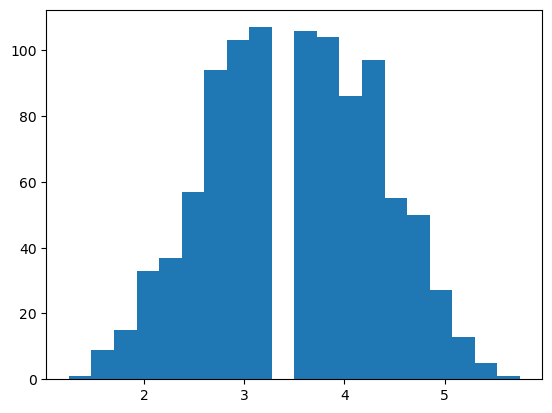

In [7]:
plt.hist(sample_means_1000,bins=20)

(array([  1.,   1.,   2.,   8.,  23.,  48., 289., 795., 155.,  16.]),
 array([59.83 , 62.905, 65.98 , 69.055, 72.13 , 75.205, 78.28 , 81.355,
        84.43 , 87.505, 90.58 ]),
 <BarContainer object of 10 artists>)

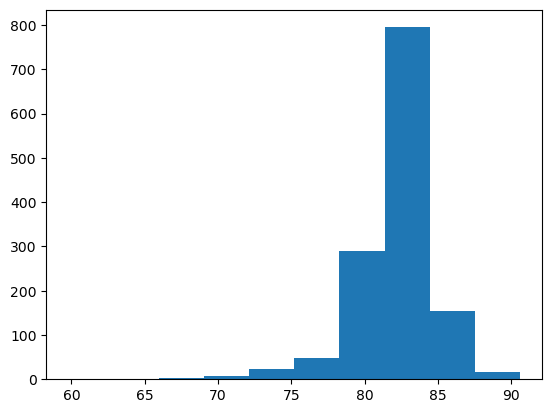

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
df_coffee=pd.read_feather("resources/coffee_ratings_full.feather")
df_coffee
plt.hist(df_coffee["total_cup_points"])

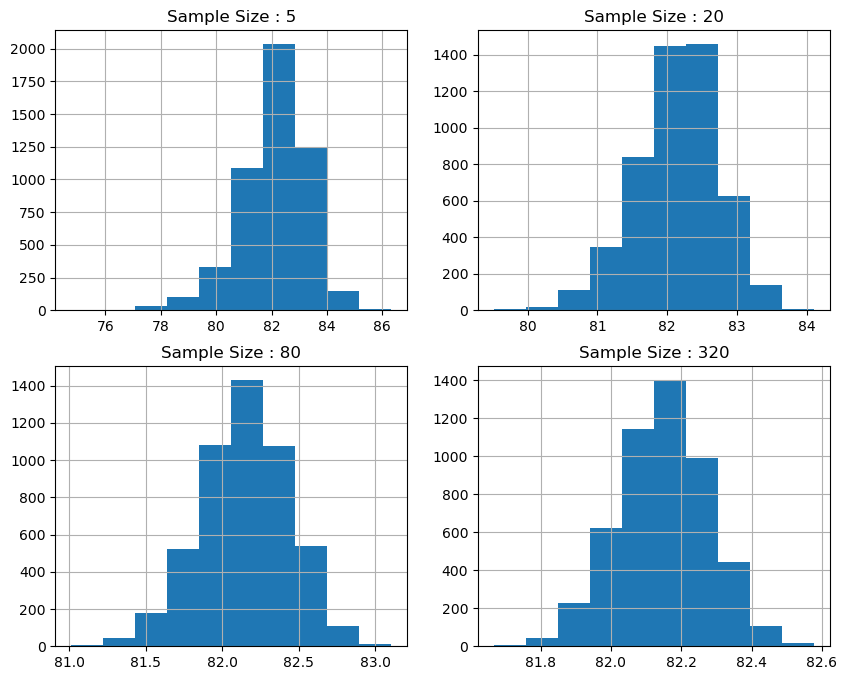

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Sample Size : 5
mean_cup_points_5 = []

for i in range(5000):
    mean_cup_points_5.append(df_coffee.sample(n=5)['total_cup_points'].mean())

axs[0, 0].hist(mean_cup_points_5)
axs[0, 0].set_title('Sample Size : 5')
axs[0, 0].grid(True)


# Sample Size : 20
mean_cup_points_20 = []

for i in range(5000):
    mean_cup_points_20.append(df_coffee.sample(n=20)['total_cup_points'].mean())

axs[0, 1].hist(mean_cup_points_20)
axs[0, 1].set_title('Sample Size : 20')
axs[0, 1].grid(True)

# Sample Size : 80
mean_cup_points_80 = []

for i in range(5000):
    mean_cup_points_80.append(df_coffee.sample(n=80)['total_cup_points'].mean())

axs[1, 0].hist(mean_cup_points_80)
axs[1, 0].set_title('Sample Size : 80')
axs[1, 0].grid(True)

# Sample Size : 320
mean_cup_points_320 = []

for i in range(5000):
    mean_cup_points_320.append(df_coffee.sample(n=320)['total_cup_points'].mean())

axs[1, 1].hist(mean_cup_points_320)
axs[1, 1].set_title('Sample Size : 320')
axs[1, 1].grid(True)

In [10]:
import numpy as np

print(f"Population Standart Deviation : {df_coffee['total_cup_points'].std(ddof=0)}")
print(f"5 Sample Standart Deviation : {np.std(mean_cup_points_5, ddof=1)}")
print(f"20 Sample Standart Deviation : {np.std(mean_cup_points_20, ddof=1)}")
print(f"80 Sample Standart Deviation : {np.std(mean_cup_points_80, ddof=1)}")
print(f"320 Sample Standart Deviation : {np.std(mean_cup_points_320, ddof=1)}")

Population Standart Deviation : 2.685858187306436
5 Sample Standart Deviation : 1.203554612122704
20 Sample Standart Deviation : 0.5933929963217098
80 Sample Standart Deviation : 0.2910824592768855
320 Sample Standart Deviation : 0.12853439248869036


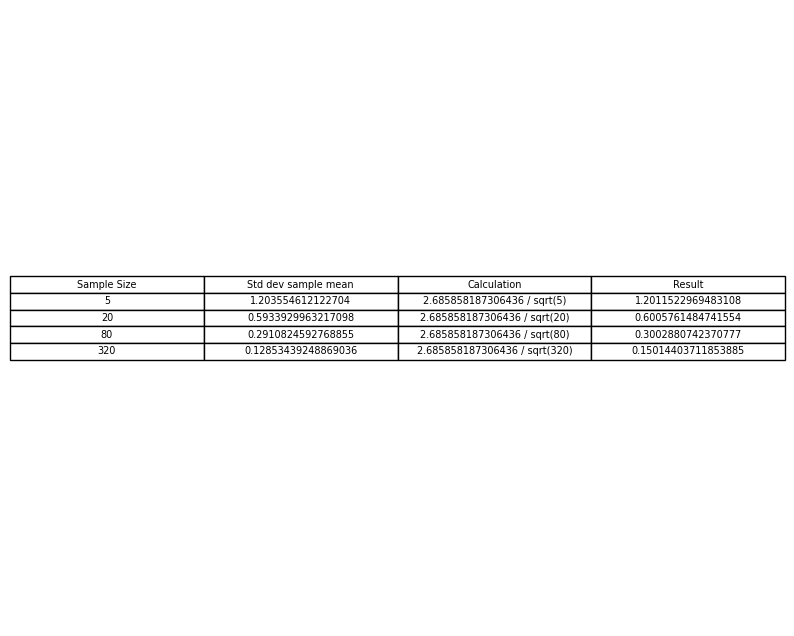

In [11]:
data = [
    [5, np.std(mean_cup_points_5, ddof=1), f"{df_coffee['total_cup_points'].std(ddof=0)} / sqrt(5)", 
     df_coffee['total_cup_points'].std(ddof=0) / np.sqrt(5)],
    [20, np.std(mean_cup_points_20, ddof=1), f"{df_coffee['total_cup_points'].std(ddof=0)} / sqrt(20)", 
    df_coffee['total_cup_points'].std(ddof=0) / np.sqrt(20)],
    [80, np.std(mean_cup_points_80, ddof=1), f"{df_coffee['total_cup_points'].std(ddof=0)} / sqrt(80)",
    df_coffee['total_cup_points'].std(ddof=0) / np.sqrt(80)],
    [320, np.std(mean_cup_points_320, ddof=1), f"{df_coffee['total_cup_points'].std(ddof=0)} / sqrt(320)",
    df_coffee['total_cup_points'].std(ddof=0) / np.sqrt(320)]
]
column_labels = ["Sample Size", "Std dev sample mean", "Calculation", "Result"]

# Boş bir figür oluştur
fig, ax = plt.subplots(figsize=(10, 8))

# Tabloyu oluştur
ax.axis('tight')
ax.axis('off')
ax.table(cellText=data, colLabels=column_labels, cellLoc='center', loc='center')

In [12]:
#haftaya bootstrapping sonta ml yapay zeka falan fistan